# Train Sentinel-1 RoughNet on PC-RTC + Real Attrs -- Corrected Spatial-Block Split

Re-run of `pcrtc/06` (the best result of the study, ZNCC=0.519) after
`pcrtc/08` found that its original train/validation split had **100%
spatial leakage** -- every validation patch overlapped at least one
training patch, because the underlying LiDAR patches were extracted with
a dense, overlapping sliding window (up to 8 neighbors per patch).

This notebook replaces the naive `random.shuffle()` patch-ID split with a
**spatial-block split**: patches are grouped into large geographic blocks
first, entire blocks are assigned to train or validation (never split), and
a buffer zone near block boundaries is dropped entirely -- mirroring the
region-based splitting Tessa's own `scripts/main.py` already uses for her
Sentinel-2 model, which this project's Sentinel-1 notebooks had not
adopted. A verification cell (reusing `pcrtc/08`'s overlap-check code)
confirms zero leakage before training proceeds -- it will halt with an
assertion error if the block size isn't generous enough.

## GPU configuration

In [1]:
import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import rasterio

assert torch.cuda.is_available(), 'CUDA is required. Run this notebook on the GPU environment.'
DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True
print('GPU:', torch.cuda.get_device_name(0))

GPU: NVIDIA GeForce RTX 4070 Ti SUPER


## Paths and training configuration

In [2]:
WORKING_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche')
TESSA_REPO = Path('/cs/student/project_msc/2025/aibh/jiayiche/tessa_baseline')
REGION = 'tuk'
LIDAR_DIR = WORKING_REPO / 'input_data' / 'lidar_patches_tuk_tessa'
S1_DIR = WORKING_REPO / 'input_data' / 's1_patches_tuk_pcrtc'
CHECKPOINT_DIR = WORKING_REPO / 'checkpoints'
OUTPUT_DIR = WORKING_REPO / 's1_training_outputs'
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CONTEXT_K = 3
TARGET_HW = (256, 256)
BATCH_SIZE = 8
EPOCHS = 100
TIMESTEPS = 1000
LEARNING_RATE = 1e-4
VAL_FRACTION = 0.15
SEED = 42
NOISE_SCHEDULE = 'linear'
ATTENTION_VARIANT = 'default'
LIDAR_SURVEY_DATE = __import__('datetime').date(2024, 4, 16)

# Spatial-block split parameters -- see the split cell below for reasoning
BLOCK_SIZE_M = 1024.0  # 4x the ~256m patch size, generous margin
BUFFER_M = 150.0       # patches within this of a block boundary are dropped entirely

## Import Tessa's baseline implementation

In [3]:
sys.path.insert(0, str(TESSA_REPO))
from src.model.unet import ConditionalUNet
from src.diffusion.scheduler import LinearDiffusionScheduler, CosineDiffusionScheduler
from src.diffusion.sampling import p_sample_loop_ddpm, p_sample_loop_ddim, p_sample_loop_plms
from src.utils.recon_metrics import rmse, bias, sigma_error, normal_angle_error, average_jsd_multiscale, log_psd_rmse, zncc

def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

## Sentinel-1/LiDAR dataset adapter -- repeated channels, real attrs (unchanged from 06)

In [4]:
def build_real_attrs(s1_path, times, context_k):
    attrs_path = s1_path / 'attrs.json'
    attrs_list = json.load(open(attrs_path)) if attrs_path.exists() else []
    vecs = []
    for time_path in times:
        idx = int(time_path.stem[1:])  # 't0' -> 0
        a = attrs_list[idx] if idx < len(attrs_list) else {}
        if a.get('acquisition_date'):
            import datetime as dt
            acq_date = dt.date.fromisoformat(a['acquisition_date'])
            age_days = (acq_date - LIDAR_SURVEY_DATE).days
            age_norm = age_days / 30.0
        else:
            age_norm = 0.0
        orbit_dir = 1.0 if a.get('orbit_direction') == 'ASCENDING' else 0.0
        rel_orbit = (a.get('relative_orbit_number') or 0) / 175.0
        vecs.append([age_norm, orbit_dir, rel_orbit, 0.0, 0.0, 0.0, 0.0, 0.0])
    return torch.tensor(vecs, dtype=torch.float32).flatten()


class LidarS1Dataset(Dataset):
    def __init__(self, s1_dir, lidar_dir, patch_ids, context_k=3, target_hw=(256, 256), train=False):
        self.s1_dir = Path(s1_dir)
        self.lidar_dir = Path(lidar_dir)
        self.patch_ids = list(patch_ids)
        self.context_k = context_k
        self.target_hw = target_hw
        self.train = train

    def __len__(self):
        return len(self.patch_ids)

    def __getitem__(self, index):
        patch_id = self.patch_ids[index]
        lidar_path = self.lidar_dir / f'lidar_patch_{patch_id}.tif'
        s1_path = self.s1_dir / f's1_patch_{patch_id}'
        with rasterio.open(lidar_path) as src:
            raw = src.read().astype(np.float32)
        target = raw[0]
        mask = (raw[1] > 0.5) if raw.shape[0] > 1 else np.isfinite(target)
        target = np.nan_to_num(target, nan=0.0, posinf=0.0, neginf=0.0)
        valid_count = max(1, int(mask.sum()))
        patch_mean = float(target[mask].sum() / valid_count)
        target = (target - patch_mean) * mask

        times = sorted(s1_path.glob('t*.tif'))[:self.context_k]
        if len(times) < self.context_k:
            raise RuntimeError(f'{s1_path} has fewer than {self.context_k} Sentinel-1 times')
        views = []
        for time_path in times:
            with rasterio.open(time_path) as src:
                sar = src.read()[:2].astype(np.float32)
            sar = np.nan_to_num(sar, nan=0.0, posinf=0.0, neginf=0.0)
            sar = np.maximum(sar, 1e-12)
            sar = 10.0 * np.log10(sar)
            sar_tensor = torch.from_numpy(sar).unsqueeze(0)
            sar_tensor = F.interpolate(sar_tensor, size=self.target_hw, mode='bilinear', align_corners=False).squeeze(0)
            sar_tensor = sar_tensor.repeat(2, 1, 1)
            views.append(sar_tensor)
        condition = torch.cat(views, dim=0)
        attrs = build_real_attrs(s1_path, times, self.context_k)
        return {'lidar': torch.from_numpy(target).unsqueeze(0).float(), 'mask': torch.from_numpy(mask), 's1': condition.float(), 'attrs': attrs, 'patch_mean': torch.tensor(patch_mean), 'patch_id': patch_id}

## Spatial-block split (corrected)

Groups patches into `BLOCK_SIZE_M`-sized geographic blocks by centroid,
shuffles and assigns whole blocks to train/val (never splitting a block),
and drops any patch within `BUFFER_M` of a block boundary entirely --
guaranteeing no train patch and val patch can be adjacent across a block
edge, regardless of how dense the original patch overlap was.

In [5]:
lidar_ids = {p.stem.split('_')[-1] for p in LIDAR_DIR.glob('lidar_patch_*.tif')}
s1_ids = {p.name.split('_')[-1] for p in S1_DIR.glob('s1_patch_*') if p.is_dir()}
paired_ids = sorted(lidar_ids & s1_ids)
assert paired_ids, 'No paired Sentinel-1/LiDAR patches found.'

def patch_centroid(patch_id):
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{patch_id}.tif') as src:
        b = src.bounds
    return ((b.left + b.right) / 2.0, (b.bottom + b.top) / 2.0)

centroids = {pid: patch_centroid(pid) for pid in paired_ids}

def block_id_and_boundary_distance(cx, cy, block_size):
    bx, by = int(cx // block_size), int(cy // block_size)
    dx = min(cx - bx * block_size, (bx + 1) * block_size - cx)
    dy = min(cy - by * block_size, (by + 1) * block_size - cy)
    return (bx, by), min(dx, dy)

blocks = {}
dropped_buffer = []
for pid, (cx, cy) in centroids.items():
    bid, boundary_dist = block_id_and_boundary_distance(cx, cy, BLOCK_SIZE_M)
    if boundary_dist < BUFFER_M:
        dropped_buffer.append(pid)
        continue
    blocks.setdefault(bid, []).append(pid)

kept_total = sum(len(v) for v in blocks.values())
print(f'{len(dropped_buffer)} / {len(paired_ids)} patches dropped as boundary buffer')
print(f'{len(blocks)} spatial blocks remain, containing {kept_total} patches')

block_ids = list(blocks.keys())
random.Random(SEED).shuffle(block_ids)

target_val_patches = int(len(paired_ids) * VAL_FRACTION)  # same target fraction as 06, for comparability
val_ids, train_ids = [], []
running_val_count = 0
for bid in block_ids:
    if running_val_count < target_val_patches:
        val_ids.extend(blocks[bid])
        running_val_count += len(blocks[bid])
    else:
        train_ids.extend(blocks[bid])

print(f'Spatial-block split: train={len(train_ids)}, val={len(val_ids)} '
      f'(target val={target_val_patches}, {len(dropped_buffer)} dropped as buffer)')

train_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, train_ids, CONTEXT_K, TARGET_HW, train=True)
val_dataset = LidarS1Dataset(S1_DIR, LIDAR_DIR, val_ids, CONTEXT_K, TARGET_HW, train=False)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

887 / 1676 patches dropped as boundary buffer
43 spatial blocks remain, containing 789 patches
Spatial-block split: train=534, val=255 (target val=251, 887 dropped as buffer)


### Verify the split is actually leakage-free

Reuses `pcrtc/08`'s spatial-overlap check directly, applied to this new
split. **This must print `0 / N` before continuing** -- the assertion
below will stop the notebook otherwise, rather than silently training on
a still-contaminated split. If it fails, increase `BLOCK_SIZE_M` or
`BUFFER_M` above and re-run from the split cell.

In [6]:
from shapely.geometry import box
from shapely.strtree import STRtree

train_boxes = []
for pid in train_ids:
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{pid}.tif') as src:
        train_boxes.append(box(*src.bounds))

val_boxes = []
for pid in val_ids:
    with rasterio.open(LIDAR_DIR / f'lidar_patch_{pid}.tif') as src:
        val_boxes.append((pid, box(*src.bounds)))

tree = STRtree(train_boxes)
overlap_count = 0
for pid, vbox in val_boxes:
    hits = tree.query(vbox)
    real_overlaps = [h for h in hits if train_boxes[h].intersects(vbox) and not train_boxes[h].touches(vbox)]
    if real_overlaps:
        overlap_count += 1
        print(f'Val patch {pid} still overlaps {len(real_overlaps)} training patch(es)')

print(f'\n{overlap_count} / {len(val_ids)} validation patches overlap a training patch (must be 0)')
assert overlap_count == 0, (
    'Spatial-block split still has leakage -- increase BLOCK_SIZE_M or BUFFER_M '
    'in the config cell above and re-run from the split cell.'
)
print('Confirmed: spatial-block split is leakage-free. Safe to proceed to training.')

split_check_result = {'n_train': len(train_ids), 'n_val': len(val_ids),
                       'n_dropped_buffer': len(dropped_buffer), 'n_overlaps_found': overlap_count,
                       'block_size_m': BLOCK_SIZE_M, 'buffer_m': BUFFER_M}
with (OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_split_check.json').open('w') as f:
    json.dump(split_check_result, f, indent=2)
print('Saved:', OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_split_check.json')


0 / 255 validation patches overlap a training patch (must be 0)
Confirmed: spatial-block split is leakage-free. Safe to proceed to training.
Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_split_check.json


## Initialize Tessa's ConditionalUNet and scheduler

In [7]:
model = ConditionalUNet(in_channels=1, cond_channels=4 * CONTEXT_K, attr_dim=8 * CONTEXT_K, base_channels=128, embed_dim=256, unet_depth=4, attention_variant=ATTENTION_VARIANT, cond_k=CONTEXT_K).to(DEVICE)
scheduler = (LinearDiffusionScheduler(TIMESTEPS, device=DEVICE) if NOISE_SCHEDULE == 'linear' else CosineDiffusionScheduler(TIMESTEPS, device=DEVICE))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
print('Trainable parameters:', sum(p.numel() for p in model.parameters() if p.requires_grad))

Trainable parameters: 104625307


## Training loop

In [8]:
from torch.cuda.amp import autocast, GradScaler

def masked_mse(prediction, target, mask):
    valid = mask.bool().unsqueeze(1)
    error = (prediction - target) ** 2
    return error[valid].mean()

scaler = GradScaler()
history = {'train_loss': [], 'val_loss': []}
best_val = float('inf')
for epoch in range(EPOCHS):
    model.train()
    train_total = 0.0
    for batch in train_loader:
        target = batch['lidar'].to(DEVICE, non_blocking=True)
        condition = batch['s1'].to(DEVICE, non_blocking=True)
        attrs = batch['attrs'].to(DEVICE, non_blocking=True)
        mask = batch['mask'].to(DEVICE, non_blocking=True)
        timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast():
            noisy = scheduler.q_sample(target, timestep)
            prediction = model(noisy, condition, attrs, timestep)
            loss = masked_mse(prediction, target, mask)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        train_total += loss.item()
    model.eval()
    val_total = 0.0
    with torch.no_grad():
        for batch in val_loader:
            target = batch['lidar'].to(DEVICE, non_blocking=True)
            condition = batch['s1'].to(DEVICE, non_blocking=True)
            attrs = batch['attrs'].to(DEVICE, non_blocking=True)
            mask = batch['mask'].to(DEVICE, non_blocking=True)
            timestep = torch.randint(0, TIMESTEPS, (target.size(0),), device=DEVICE)
            with autocast():
                prediction = model(scheduler.q_sample(target, timestep), condition, attrs, timestep)
                val_total += masked_mse(prediction, target, mask).item()
    train_loss = train_total / max(1, len(train_loader))
    val_loss = val_total / max(1, len(val_loader))
    history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)
    print(f'Epoch {epoch + 1:03d}/{EPOCHS}: train={train_loss:.6f} val={val_loss:.6f}')
    if val_loss < best_val:
        best_val = val_loss
        torch.save({'model_state_dict': model.state_dict(), 'config': {'context_k': CONTEXT_K, 'timesteps': TIMESTEPS, 'noise_schedule': NOISE_SCHEDULE, 'region': REGION}, 'epoch': epoch + 1, 'val_loss': val_loss}, CHECKPOINT_DIR / f's1_{REGION}_pcrtc_realattrs_spatialsplit_unet_best.pth')

/tmp/ipykernel_778835/1406031128.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_778835/1406031128.py:21: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_778835/1406031128.py:38: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():


Epoch 001/100: train=0.061031 val=0.026387
Epoch 002/100: train=0.019044 val=0.018422
Epoch 003/100: train=0.016327 val=0.017985
Epoch 004/100: train=0.015269 val=0.016558
Epoch 005/100: train=0.014984 val=0.017435
Epoch 006/100: train=0.015063 val=0.017016
Epoch 007/100: train=0.014451 val=0.015175
Epoch 008/100: train=0.013988 val=0.017218
Epoch 009/100: train=0.014138 val=0.017240
Epoch 010/100: train=0.013775 val=0.016367
Epoch 011/100: train=0.014052 val=0.014971
Epoch 012/100: train=0.013661 val=0.015797
Epoch 013/100: train=0.013879 val=0.014419
Epoch 014/100: train=0.013723 val=0.016395
Epoch 015/100: train=0.014185 val=0.015770
Epoch 016/100: train=0.013400 val=0.016394
Epoch 017/100: train=0.013499 val=0.015711
Epoch 018/100: train=0.013531 val=0.015921
Epoch 019/100: train=0.013909 val=0.016149
Epoch 020/100: train=0.013616 val=0.016441
Epoch 021/100: train=0.013608 val=0.015703
Epoch 022/100: train=0.012636 val=0.014674
Epoch 023/100: train=0.013348 val=0.014463
Epoch 024/1

## Evaluate with Tessa's reconstruction metrics

In [9]:
best_path = CHECKPOINT_DIR / f's1_{REGION}_pcrtc_realattrs_spatialsplit_unet_best.pth'
checkpoint = torch.load(best_path, map_location=DEVICE)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
sampler = p_sample_loop_ddim
metric_rows = []
example_patches = []  # keep a few full patches for the qualitative reconstruction grid
N_EXAMPLES = 6
with torch.no_grad():
    for batch in val_loader:
        target = batch['lidar'].to(DEVICE)
        condition = batch['s1'].to(DEVICE)
        attrs = batch['attrs'].to(DEVICE)
        mask = batch['mask'].to(DEVICE).bool()
        prediction = sampler(model, scheduler, target.shape, condition, attrs, DEVICE)
        means = batch['patch_mean'].to(DEVICE).view(-1, 1, 1, 1)
        gt_absolute = target + means
        pred_absolute = prediction + means
        for i, patch_id in enumerate(batch['patch_id']):
            gt_i, pred_i, mask_i = gt_absolute[i], pred_absolute[i], mask[i]
            gt_valid = gt_i.squeeze()[mask_i].cpu().numpy()
            pred_valid = pred_i.squeeze()[mask_i].cpu().numpy()
            row = {
                'patch_id': patch_id,
                'rmse_m': float(rmse(gt_i, pred_i, mask_i).item()),
                'bias_m': float(bias(gt_i, pred_i, mask_i).item()),
                'sigma_error_pct': float(sigma_error(gt_i, pred_i, mask_i).item()),
                'normal_angle_error_deg': float(normal_angle_error(gt_i, pred_i, mask_i, pixel_size=1.0, degrees=True).item()),
                'jsd': float(average_jsd_multiscale(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'psd_rmse': float(log_psd_rmse(gt_i, pred_i, pixel_size=1.0, mask=mask_i).item()),
                'zncc': float(zncc(gt_i, pred_i, mask_i).item()),
                'gt_std_val': float(gt_valid.std()) if gt_valid.size > 0 else float('nan'),
                'pred_std_val': float(pred_valid.std()) if pred_valid.size > 0 else float('nan'),
            }
            metric_rows.append(row)
            if len(example_patches) < N_EXAMPLES:
                example_patches.append({
                    'patch_id': patch_id,
                    'gt': gt_i.squeeze().cpu().numpy(),
                    'pred': pred_i.squeeze().cpu().numpy(),
                    'mask': mask_i.squeeze().cpu().numpy(),
                    's1_condition': condition[i].cpu().numpy(),
                })
metrics_path = OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_validation_metrics.json'
with metrics_path.open('w') as handle:
    json.dump(metric_rows, handle, indent=2)
print('Saved:', metrics_path)
print('Mean metrics:', {key: float(np.nanmean([row[key] for row in metric_rows])) for key in metric_rows[0] if key != 'patch_id'})

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_validation_metrics.json
Mean metrics: {'rmse_m': 0.19447095072736928, 'bias_m': -0.0012896472615858668, 'sigma_error_pct': 22.729624709545398, 'normal_angle_error_deg': 1.9890308515698303, 'jsd': 0.11796334976074742, 'psd_rmse': 1.3092249582795537, 'zncc': 0.23439713810095747, 'gt_std_val': 0.17209622516643766, 'pred_std_val': 0.13838612535128406}


In [10]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_gt_pred_std_scatter.png


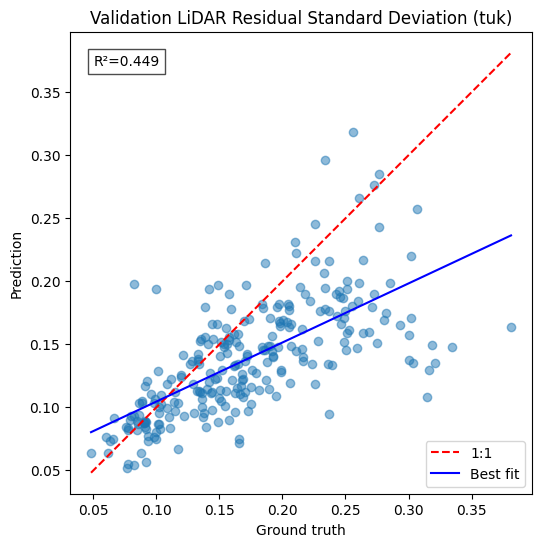

In [11]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df_val = pd.DataFrame(metric_rows)

x = df_val['gt_std_val']
y = df_val['pred_std_val']

plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.5)

mn, mx = np.nanmin([x, y]), np.nanmax([x, y])
plt.plot([mn, mx], [mn, mx], 'r--', label='1:1')

mask = ~np.isnan(x) & ~np.isnan(y)
z = np.polyfit(x[mask], y[mask], 1)
p = np.poly1d(z)
xs = np.array([mn, mx])
plt.plot(xs, p(xs), 'b-', label='Best fit')

r2 = np.corrcoef(x[mask], y[mask])[0, 1] ** 2
plt.text(0.05, 0.95, f'R²={r2:.3f}', transform=plt.gca().transAxes, va='top', bbox=dict(facecolor='white', alpha=0.7))

plt.xlabel('Ground truth')
plt.ylabel('Prediction')
plt.title(f'Validation LiDAR Residual Standard Deviation ({REGION})')
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.savefig(OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_gt_pred_std_scatter.png', dpi=150, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_gt_pred_std_scatter.png')
plt.show()


Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_reconstructions_pdfs.png


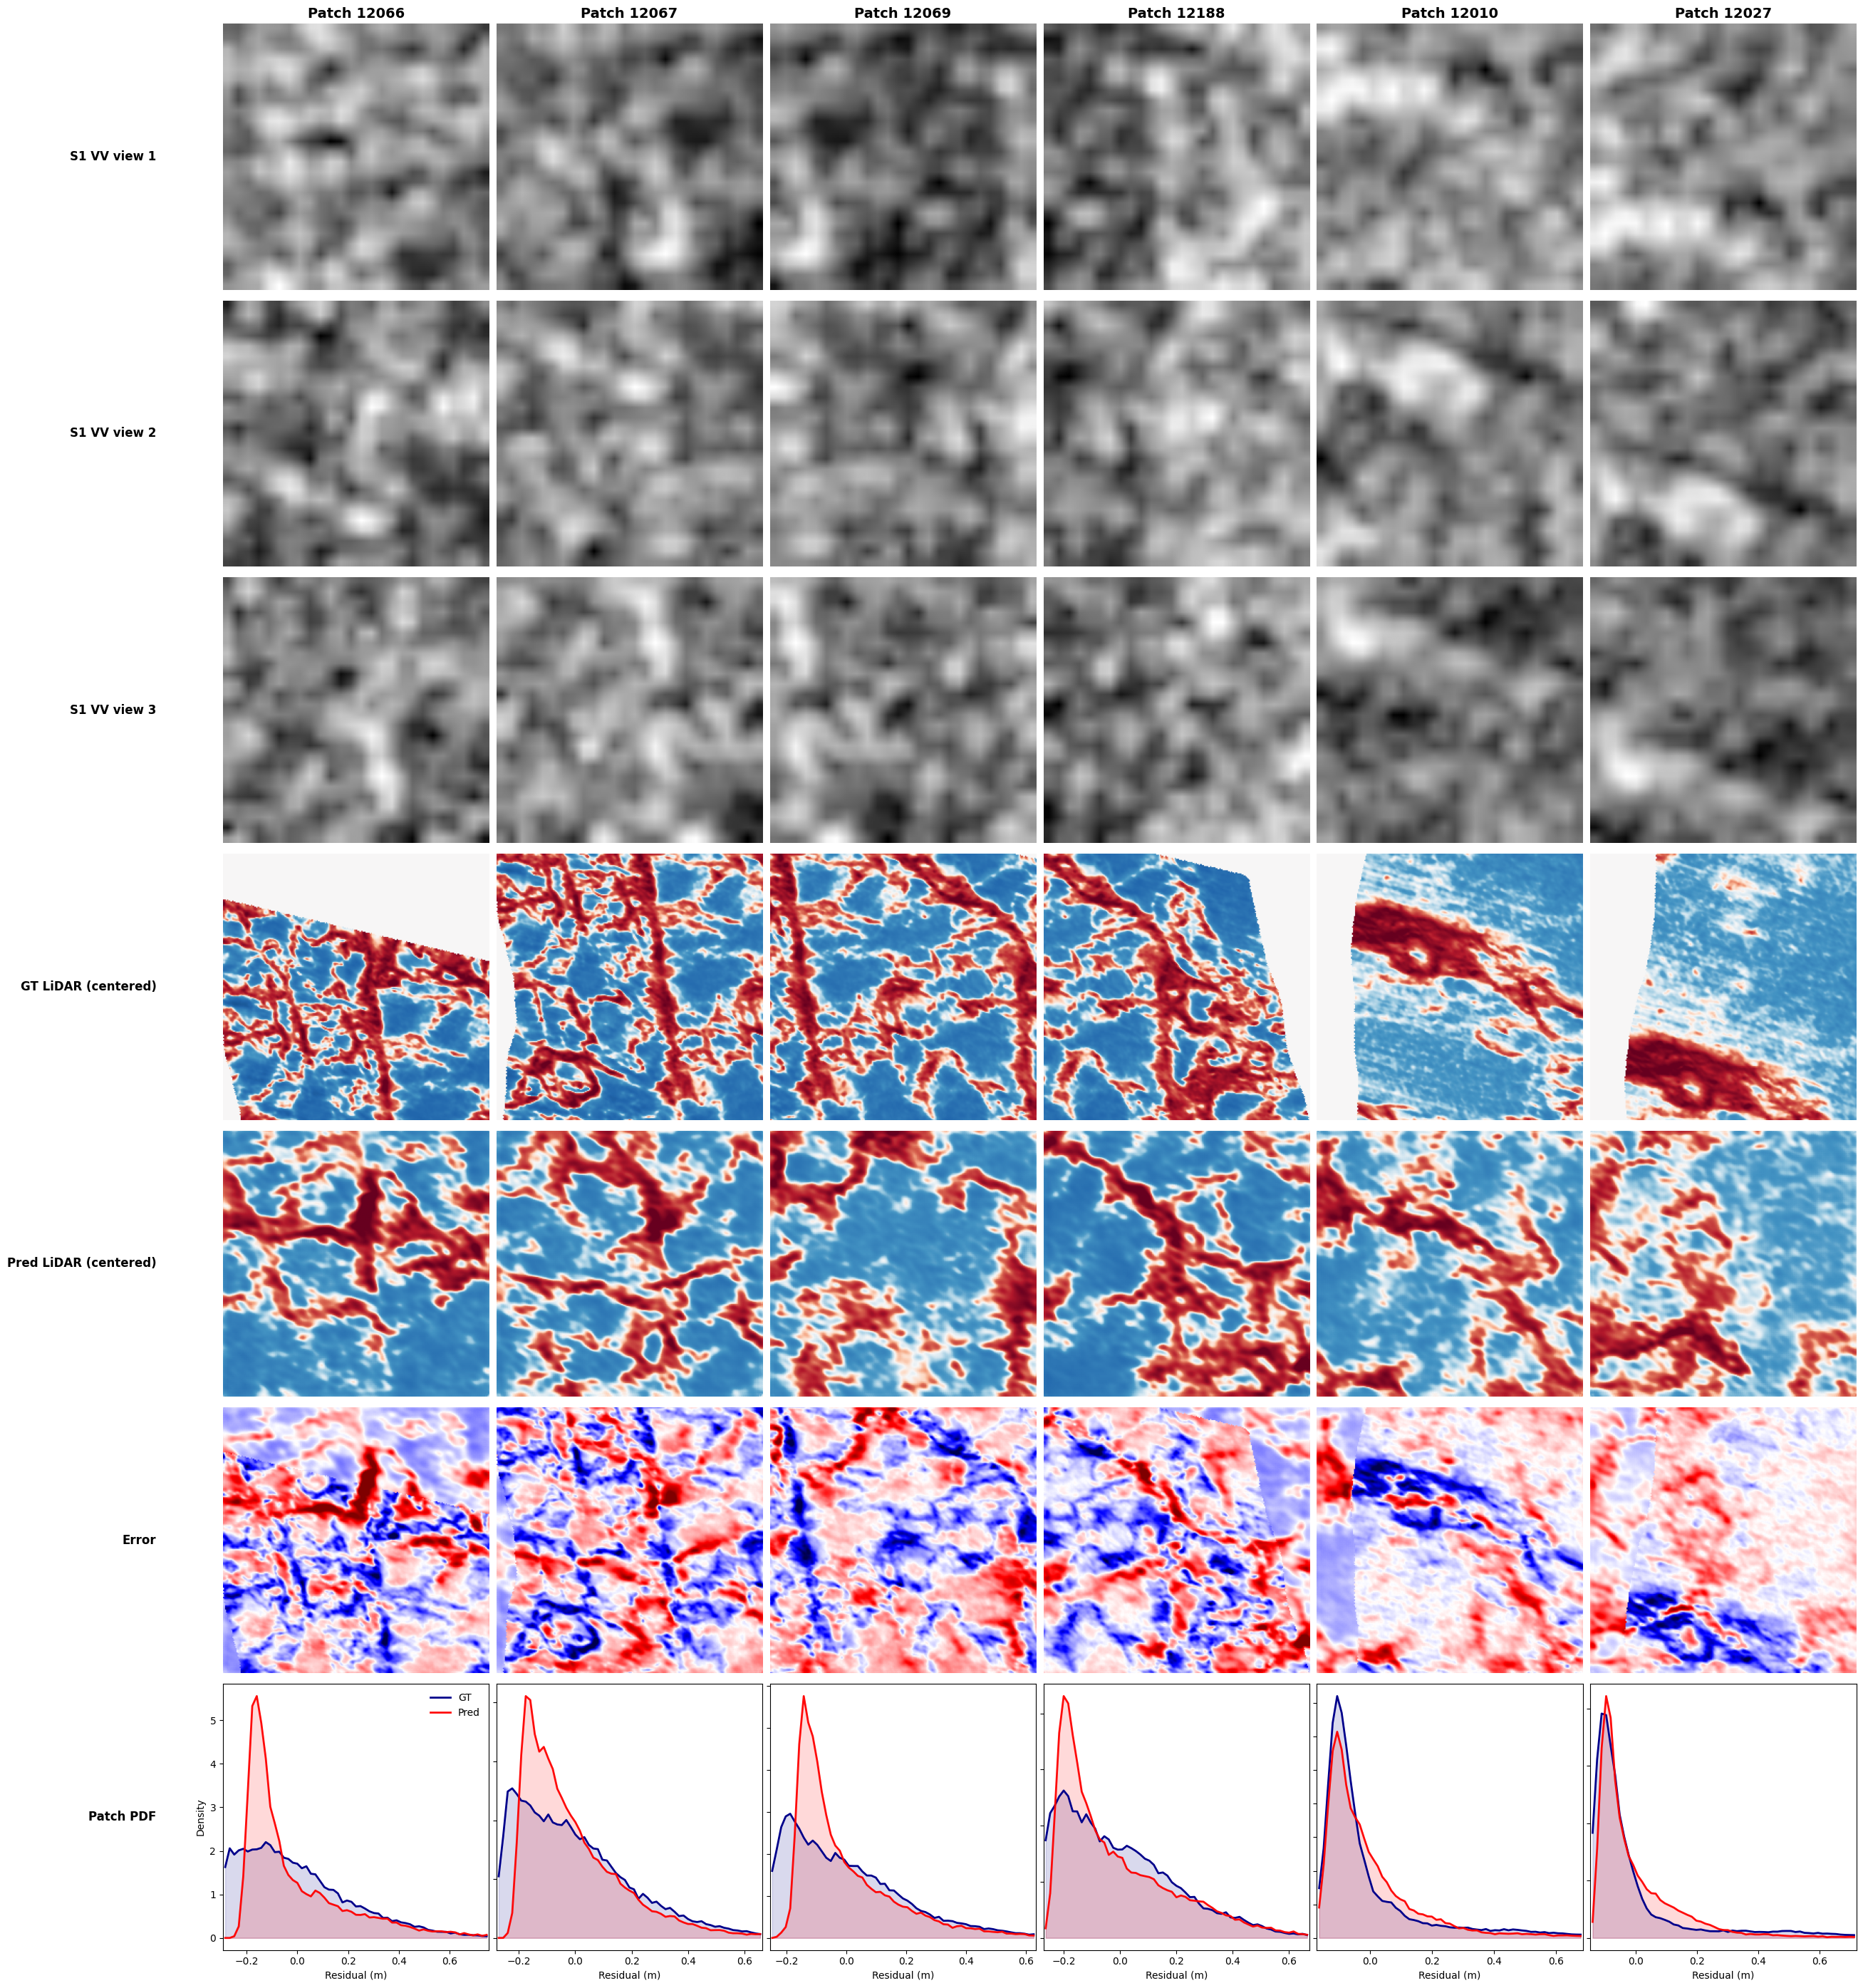

In [12]:
from matplotlib.colors import SymLogNorm

n_show = min(6, len(example_patches))
num_context_rows = CONTEXT_K
num_data_rows = 4
total_rows = num_context_rows + num_data_rows
num_cols = n_show

centered_gt = []
centered_pred = []
for p in example_patches[:n_show]:
    gt_mean = p['gt'][p['mask']].mean()
    pred_mean = p['pred'][p['mask']].mean()
    centered_gt.append(p['gt'] - gt_mean)
    centered_pred.append(p['pred'] - pred_mean)

all_gt = np.stack(centered_gt)
all_pred = np.stack(centered_pred)
max_abs_resid = np.quantile(np.abs(np.concatenate([all_gt.ravel(), all_pred.ravel()])), 0.995)
signed_error = all_pred - all_gt
max_abs_error = np.quantile(np.abs(signed_error.ravel()), 0.995)
norm = SymLogNorm(linthresh=0.1, linscale=1.0, vmin=-max_abs_resid, vmax=max_abs_resid, base=10)

row_titles = [f'S1 VV view {k + 1}' for k in range(CONTEXT_K)] + ['GT LiDAR (centered)', 'Pred LiDAR (centered)', 'Error', 'Patch PDF']

tile_size_inches = 4.0
fig, axes = plt.subplots(total_rows, num_cols, figsize=(num_cols * tile_size_inches + 2, total_rows * tile_size_inches), squeeze=False)

for col in range(num_cols):
    p = example_patches[col]
    gt_i, pred_i, mask_i = centered_gt[col], centered_pred[col], p['mask']
    s1_cond = p['s1_condition']

    axes[0, col].set_title(f"Patch {p['patch_id']}", fontsize=14, fontweight='bold')

    for k in range(CONTEXT_K):
        ax = axes[k, col]
        ax.imshow(s1_cond[k * 4], cmap='gray')
        ax.axis('off')

    row_gt = num_context_rows
    ax = axes[row_gt, col]
    im_gt = ax.imshow(gt_i, cmap='RdBu_r', norm=norm)
    ax.axis('off')

    row_pred = num_context_rows + 1
    ax = axes[row_pred, col]
    im_pred = ax.imshow(pred_i, cmap='RdBu_r', norm=norm)
    ax.axis('off')

    row_err = num_context_rows + 2
    err_i = pred_i - gt_i
    ax = axes[row_err, col]
    im_err = ax.imshow(err_i, cmap='seismic', vmin=-max_abs_error, vmax=max_abs_error)
    ax.axis('off')

    row_pdf = num_context_rows + 3
    ax = axes[row_pdf, col]
    gt_vals = gt_i[mask_i]
    pred_vals = pred_i[mask_i]
    if gt_vals.size > 1 and pred_vals.size > 1:
        all_vals = np.concatenate([gt_vals, pred_vals])
        vmin_pdf, vmax_pdf = np.quantile(all_vals, [0.01, 0.99])
        if np.isclose(vmin_pdf, vmax_pdf):
            vmin_pdf, vmax_pdf = all_vals.min(), all_vals.max()
        bins = np.linspace(vmin_pdf, vmax_pdf, 60)
        gt_pdf, edges = np.histogram(gt_vals, bins=bins, density=True)
        pred_pdf, _ = np.histogram(pred_vals, bins=bins, density=True)
        centers = 0.5 * (edges[:-1] + edges[1:])
        ax.plot(centers, gt_pdf, color='darkblue', lw=2, label='GT')
        ax.plot(centers, pred_pdf, color='red', lw=2, alpha=0.95, label='Pred')
        ax.fill_between(centers, gt_pdf, color='darkblue', alpha=0.15)
        ax.fill_between(centers, pred_pdf, color='red', alpha=0.15)
        ax.set_xlim(vmin_pdf, vmax_pdf)
    ax.set_xlabel('Residual (m)', fontsize=10)
    if col == 0:
        ax.set_ylabel('Density', fontsize=10)
        ax.legend(fontsize=10, frameon=False)
    else:
        ax.set_yticklabels([])
    ax.set_box_aspect(1)

for row in range(total_rows):
    axes[row, 0].text(-0.25, 0.5, row_titles[row], ha='right', va='center', transform=axes[row, 0].transAxes, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_reconstructions_pdfs.png', dpi=200, bbox_inches='tight')
print('Saved:', OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_reconstructions_pdfs.png')
plt.show()


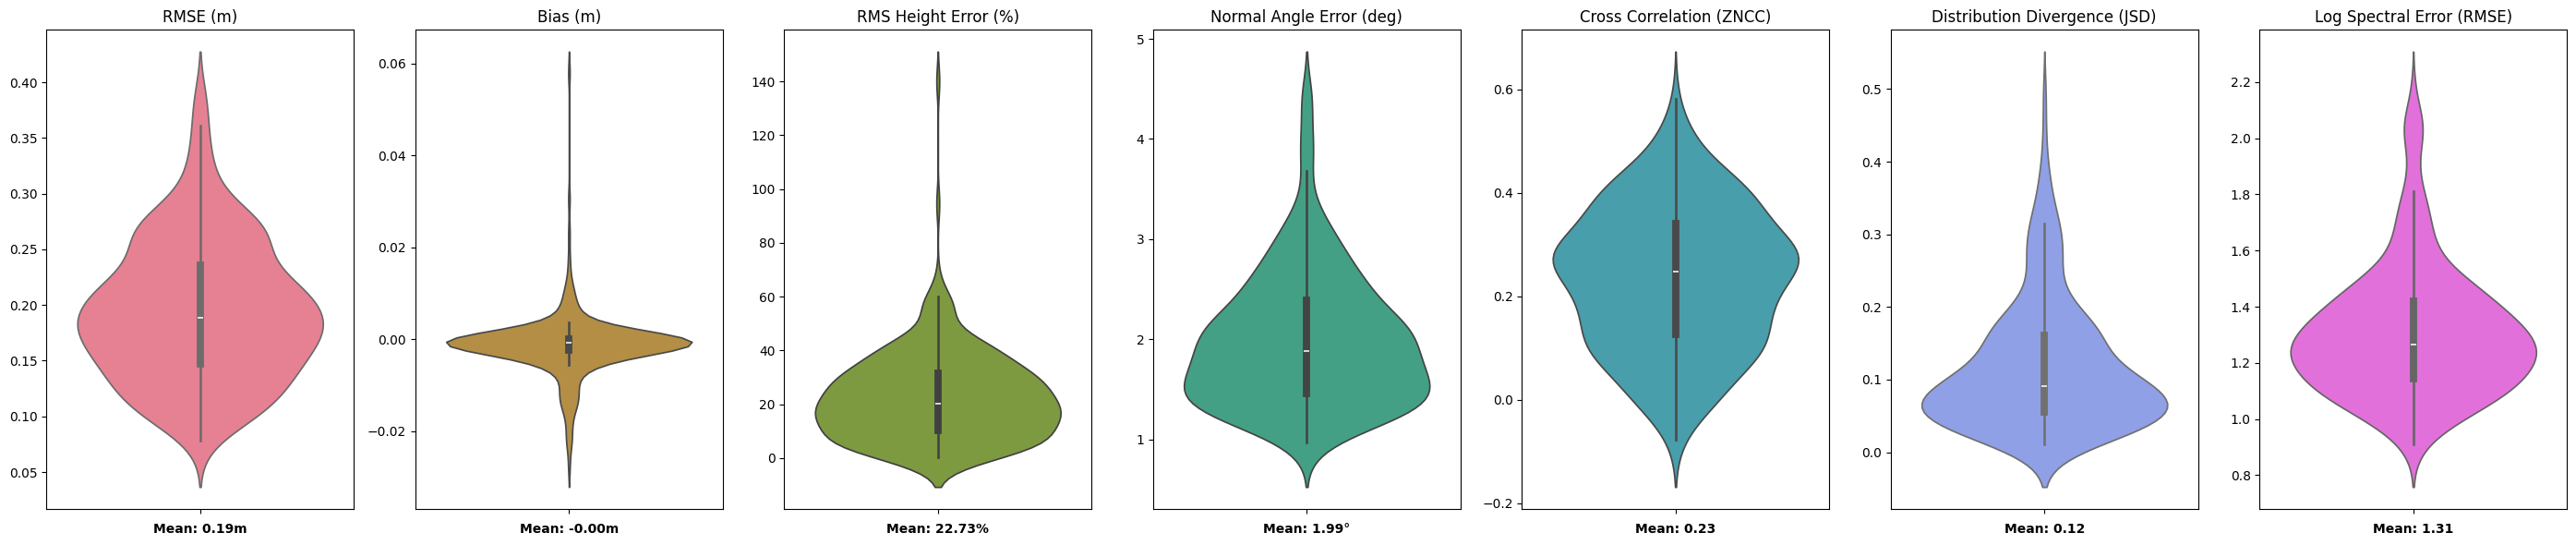

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_metric_violin_plots.png


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

if 'df_val' not in dir():
    df_val = pd.DataFrame(metric_rows)

metrics_to_plot = [
    ('rmse_m', 'RMSE (m)', 'm'),
    ('bias_m', 'Bias (m)', 'm'),
    ('sigma_error_pct', 'RMS Height Error (%)', '%'),
    ('normal_angle_error_deg', 'Normal Angle Error (deg)', '°'),
    ('zncc', 'Cross Correlation (ZNCC)', ''),
    ('jsd', 'Distribution Divergence (JSD)', ''),
    ('psd_rmse', 'Log Spectral Error (RMSE)', ''),
]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4 * len(metrics_to_plot), 6))
colors = sns.color_palette('husl', len(metrics_to_plot))

for ax, (key, title, unit), color in zip(axes, metrics_to_plot, colors):
    values = df_val[key].dropna()
    sns.violinplot(y=values, ax=ax, color=color, inner='box')
    ax.set_title(title)
    ax.set_ylabel('')
    mean_val = values.mean()
    ax.set_xlabel(f'Mean: {mean_val:.2f}{unit}', fontsize=10, fontweight='bold')

plt.tight_layout()
out_path = OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_metric_violin_plots.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


## Qualitative success/failure case analysis

Same textured-block success/failure circling used throughout this
project -- an original design for this project, not a figure from
Tessa's dissertation (confirmed by checking her PDF directly).

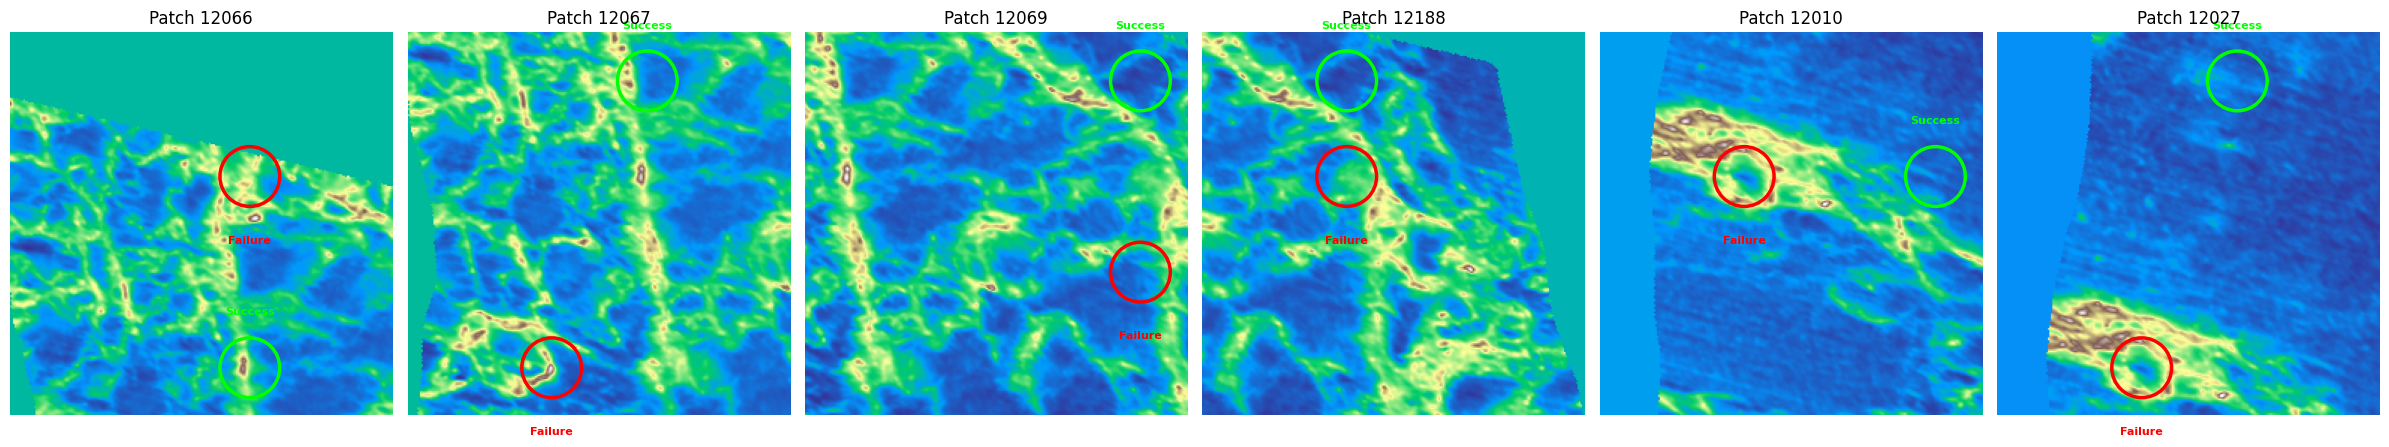

Saved: /cs/student/project_msc/2025/aibh/jiayiche/s1_training_outputs/s1_pcrtc_realattrs_spatialsplit_success_failure.png


In [14]:
import matplotlib.pyplot as plt
import numpy as np

def find_success_failure_regions(gt, pred, mask, block_size=64):
    """Split the patch into blocks; success = textured block with lowest error,
    failure = textured block with highest error. 'Textured' excludes flat/boring
    background blocks so the comparison is about real roughness, not empty ice."""
    error = np.abs(pred - gt)
    h, w = gt.shape
    block_stats = []
    for i in range(h // block_size):
        for j in range(w // block_size):
            r0, r1 = i * block_size, (i + 1) * block_size
            c0, c1 = j * block_size, (j + 1) * block_size
            block_mask = mask[r0:r1, c0:c1]
            if block_mask.sum() < 0.5 * block_mask.size:
                continue  # skip mostly-invalid blocks
            block_stats.append({
                'row': r0 + block_size // 2, 'col': c0 + block_size // 2,
                'gt_std': gt[r0:r1, c0:c1][block_mask].std(),
                'error': error[r0:r1, c0:c1][block_mask].mean(),
            })
    if not block_stats:
        return None, None
    median_std = np.median([b['gt_std'] for b in block_stats])
    textured = [b for b in block_stats if b['gt_std'] >= median_std] or block_stats
    success = min(textured, key=lambda b: b['error'])
    failure = max(textured, key=lambda b: b['error'])
    return success, failure


n_show = min(6, len(example_patches))
fig, axes = plt.subplots(1, n_show, figsize=(4 * n_show, 4.5))
if n_show == 1:
    axes = [axes]

for ax, patch in zip(axes, example_patches[:n_show]):
    gt, pred, mask = patch['gt'], patch['pred'], patch['mask']
    gt_display = gt - gt[mask].mean()  # recenter for display only, avoids the saturated-color bug from before

    ax.imshow(gt_display, cmap='terrain')
    ax.set_title(f"Patch {patch['patch_id']}")
    ax.axis('off')

    success, failure = find_success_failure_regions(gt, pred, mask)
    if success is not None:
        ax.add_patch(plt.Circle((success['col'], success['row']), 20, edgecolor='lime', facecolor='none', linewidth=2.5))
        ax.annotate('Success', (success['col'], success['row']), color='lime', fontsize=8, fontweight='bold',
                    xytext=(success['col'], success['row'] - 35), ha='center')
    if failure is not None:
        ax.add_patch(plt.Circle((failure['col'], failure['row']), 20, edgecolor='red', facecolor='none', linewidth=2.5))
        ax.annotate('Failure', (failure['col'], failure['row']), color='red', fontsize=8, fontweight='bold',
                    xytext=(failure['col'], failure['row'] + 45), ha='center')

plt.tight_layout()
out_path = OUTPUT_DIR / 's1_pcrtc_realattrs_spatialsplit_success_failure.png'  # rename per-notebook if you want, e.g. 's1_pcrtc_...'
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print('Saved:', out_path)


## Comparison protocol

Compare this corrected-split result against two things:
1. **`06`'s original (leaky-split) metrics** (`s1_pcrtc_realattrs_validation_metrics.json`)
   -- shows how much the original headline number was inflated by the
   spatial leakage found in `pcrtc/08`.
2. **Tessa's Sentinel-2 reference range** (RMSE ~0.11-0.135, ZNCC
   ~0.74-0.78) -- the actual fair comparison, now that this split matches
   the spatial-blocking principle her own `scripts/main.py` already uses.

Also worth comparing against `pcrtc/08`'s unseen-date generalization test
(ZNCC collapsed to ~0.01 on genuinely new Sentinel-1 acquisitions) -- if
this corrected split's validation ZNCC is much higher than that, it
suggests acquisition-specific overfitting is a separate, additional
problem beyond the spatial leakage; if it's similarly low, leakage was
likely responsible for most of the original inflation.

In [15]:
original_metrics_path = OUTPUT_DIR / 's1_pcrtc_realattrs_validation_metrics.json'
if original_metrics_path.exists():
    orig_rows = json.load(open(original_metrics_path))
    orig_mean = {k: float(np.nanmean([r[k] for r in orig_rows])) for k in orig_rows[0] if k != 'patch_id'}
    new_mean = {key: float(np.nanmean([row[key] for row in metric_rows])) for key in metric_rows[0] if key != 'patch_id'}
    print(f'{"metric":<20}{"original (leaky)":>18}{"spatial-block split":>22}')
    for k in new_mean:
        if k in orig_mean:
            print(f'{k:<20}{orig_mean[k]:>18.4f}{new_mean[k]:>22.4f}')
else:
    print('Original 06 metrics file not found -- compare manually against the numbers already documented for 06.')

metric                original (leaky)   spatial-block split
rmse_m                          0.1587                0.1945
bias_m                          0.0139               -0.0013
sigma_error_pct                13.1323               22.7296
normal_angle_error_deg            2.2518                1.9890
jsd                             0.0544                0.1180
psd_rmse                        1.3453                1.3092
zncc                            0.5189                0.2344
gt_std_val                      0.1692                0.1721
pred_std_val                    0.1725                0.1384
